In [2]:
"""
Download ONLY the numerics files (*n.csv.gz) from the MIMIC-IV Waveform
Database v0.1.0 on PhysioNet (open access, ODbL v1.0).

Creates the folder layout:
    ./physionet.org/files/mimic4wdb/0.1.0/waves/pXXX/pYYYYYYYY/RECID/RECIDn.csv.gz

which is exactly the DATA_ROOT your IsolationForest pipeline expects.

Usage:
    pip install requests tqdm
    python download_mimic4wdb_numerics.py
"""

import os
from pathlib import Path
import requests
from tqdm import tqdm

BASE = "https://physionet.org/files/mimic4wdb/0.1.0"
OUT_ROOT = Path("physionet.org/files/mimic4wdb/0.1.0")
TIMEOUT = 60

session = requests.Session()
session.headers.update({"User-Agent": "mimic4wdb-numerics-downloader/1.0"})


def get_text(url):
    r = session.get(url, timeout=TIMEOUT)
    r.raise_for_status()
    return r.text


def download(url, dest: Path):
    if dest.exists() and dest.stat().st_size > 0:
        return "skipped"
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + ".part")
    with session.get(url, stream=True, timeout=TIMEOUT) as r:
        r.raise_for_status()
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 16):
                f.write(chunk)
    tmp.replace(dest)
    return "downloaded"


def main():
    # 1) Top-level RECORDS -> list of patient folders, e.g. "waves/p100/p10014354/"
    print("Fetching top-level RECORDS ...")
    patient_dirs = [
        line.strip().rstrip("/")
        for line in get_text(f"{BASE}/RECORDS").splitlines()
        if line.strip()
    ]
    print(f"Found {len(patient_dirs)} patient folders.")

    # 2) Per-patient RECORDS -> record entries for that patient.
    # Each line looks like "81739927/81739927" (record folder / record name,
    # always identical in this release) -- NOT a bare id. Splitting is required.
    targets = []  # (url, dest_path)
    for pdir in tqdm(patient_dirs, desc="Listing records"):
        try:
            entries = [
                line.strip().rstrip("/")
                for line in get_text(f"{BASE}/{pdir}/RECORDS").splitlines()
                if line.strip()
            ]
        except Exception as e:
            print(f"[WARN] could not list {pdir}: {e}")
            continue
        for entry in entries:
            parts = entry.split("/")
            folder = parts[0]        # record folder name, e.g. "81739927"
            record_id = parts[-1]    # record id, e.g. "81739927"
            fname = f"{record_id}n.csv.gz"
            targets.append((
                f"{BASE}/{pdir}/{folder}/{fname}",
                OUT_ROOT / pdir / folder / fname,
            ))

    print(f"{len(targets)} numerics files to fetch.")

    # 3) Download
    ok = skip = fail = 0
    for url, dest in tqdm(targets, desc="Downloading numerics"):
        try:
            status = download(url, dest)
            ok += status == "downloaded"
            skip += status == "skipped"
        except Exception as e:
            fail += 1
            print(f"[WARN] {url}: {e}")

    print(f"\nDone. downloaded={ok}  already_present={skip}  failed={fail}")
    print("DATA_ROOT for your pipeline:",
          os.path.abspath(OUT_ROOT / "waves"))


if __name__ == "__main__":
    main()

Fetching top-level RECORDS ...
Found 198 patient folders.


Listing records: 100%|██████████| 198/198 [00:23<00:00,  8.36it/s]


200 numerics files to fetch.


[WARN] https://physionet.org/files/mimic4wdb/0.1.0/waves/p128/p12801061/80154334/80154334n.csv.gz: 404 Client Error: Not Found for url: https://physionet.org/files/mimic4wdb/0.1.0/waves/p128/p12801061/80154334/80154334n.csv.gz


[WARN] https://physionet.org/files/mimic4wdb/0.1.0/waves/p129/p12961799/86114120/86114120n.csv.gz: 404 Client Error: Not Found for url: https://physionet.org/files/mimic4wdb/0.1.0/waves/p129/p12961799/86114120/86114120n.csv.gz


[WARN] https://physionet.org/files/mimic4wdb/0.1.0/waves/p147/p14759494/87555605/87555605n.csv.gz: 404 Client Error: Not Found for url: https://physionet.org/files/mimic4wdb/0.1.0/waves/p147/p14759494/87555605/87555605n.csv.gz


[WARN] https://physionet.org/files/mimic4wdb/0.1.0/waves/p163/p16362820/85250800/85250800n.csv.gz: 404 Client Error: Not Found for url: https://physionet.org/files/mimic4wdb/0.1.0/waves/p163/p16362820/85250800/85250800n.csv.gz


[WARN] https://physionet.org/files/mimic4wdb/0.1.0/waves/p190/p19052042/84601191/84601191n.csv.gz: 404 Client Error: Not Found for url: https://physionet.org/files/mimic4wdb/0.1.0/waves/p190/p19052042/84601191/84601191n.csv.gz


[WARN] https://physionet.org/files/mimic4wdb/0.1.0/waves/p196/p19646228/87340466/87340466n.csv.gz: 404 Client Error: Not Found for url: https://physionet.org/files/mimic4wdb/0.1.0/waves/p196/p19646228/87340466/87340466n.csv.gz

Done. downloaded=0  already_present=194  failed=6
DATA_ROOT for your pipeline: /content/physionet.org/files/mimic4wdb/0.1.0/waves


Searching numeric files under: physionet.org/files/mimic4wdb/0.1.0/waves
Found numeric files: 194


Processing numeric files: 100%|██████████| 194/194 [01:18<00:00,  2.48it/s]


Feature dataframe shape: (194, 43)
Saved feature table to numeric_features_unlabeled.csv
[INFO] Dropping all-NaN columns: ['NBP Mean [mmHg]_mean', 'NBP Mean [mmHg]_std', 'NBP Mean [mmHg]_min', 'NBP Mean [mmHg]_max', 'NBP Mean [mmHg]_p25', 'NBP Mean [mmHg]_p50', 'NBP Mean [mmHg]_p75', 'Systolic [mmHg]_mean', 'Systolic [mmHg]_std', 'Systolic [mmHg]_min', 'Systolic [mmHg]_max', 'Systolic [mmHg]_p25', 'Systolic [mmHg]_p50', 'Systolic [mmHg]_p75', 'Diastolic [mmHg]_mean', 'Diastolic [mmHg]_std', 'Diastolic [mmHg]_min', 'Diastolic [mmHg]_max', 'Diastolic [mmHg]_p25', 'Diastolic [mmHg]_p50', 'Diastolic [mmHg]_p75', 'Resp_mean', 'Resp_std', 'Resp_min', 'Resp_max', 'Resp_p25', 'Resp_p50', 'Resp_p75']

Preview of first 5 rows:
 HR [bpm]_mean  HR [bpm]_std  HR [bpm]_min  HR [bpm]_max  HR [bpm]_p25  HR [bpm]_p50  HR [bpm]_p75  SpO2 [%]_mean  SpO2 [%]_std  SpO2 [%]_min
     93.336919     19.110726           0.0         158.0          78.0          92.0         106.0      97.916630      1.735816    

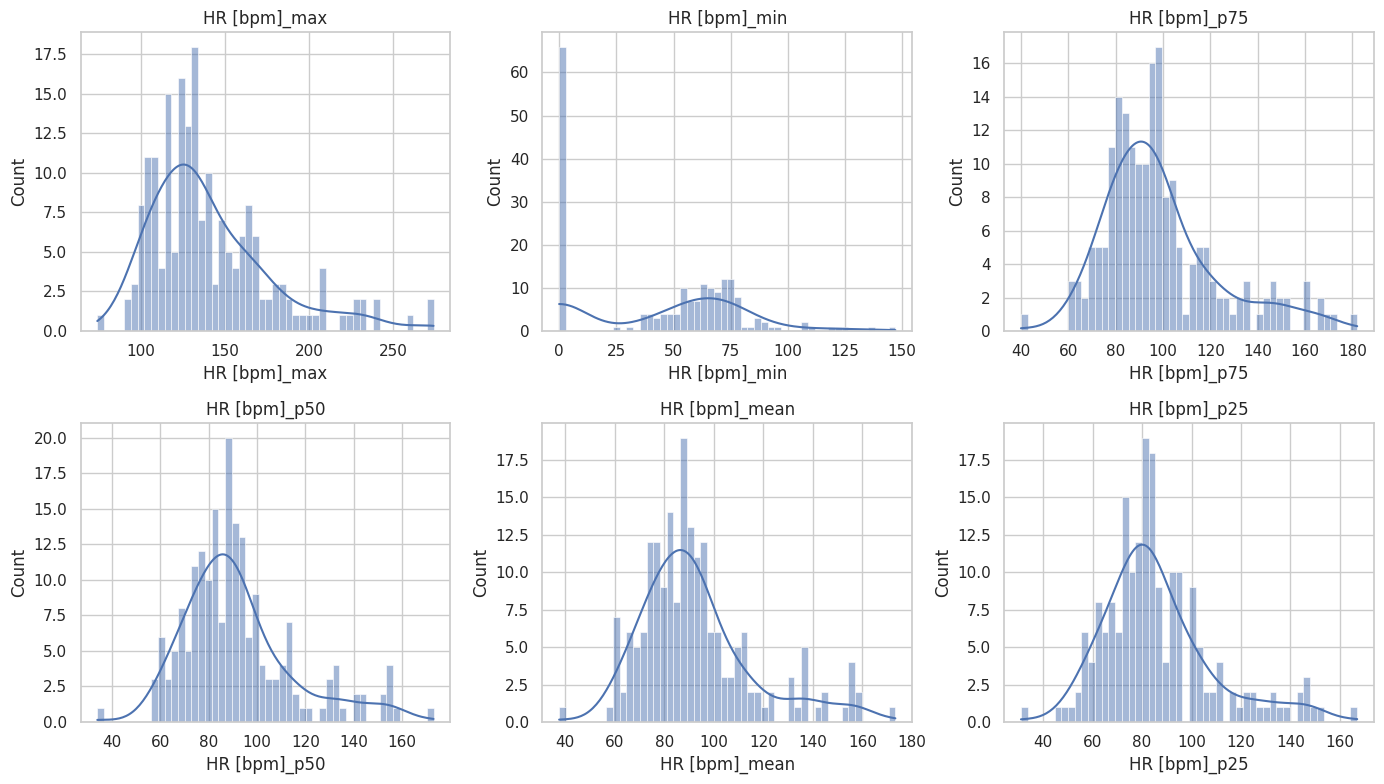

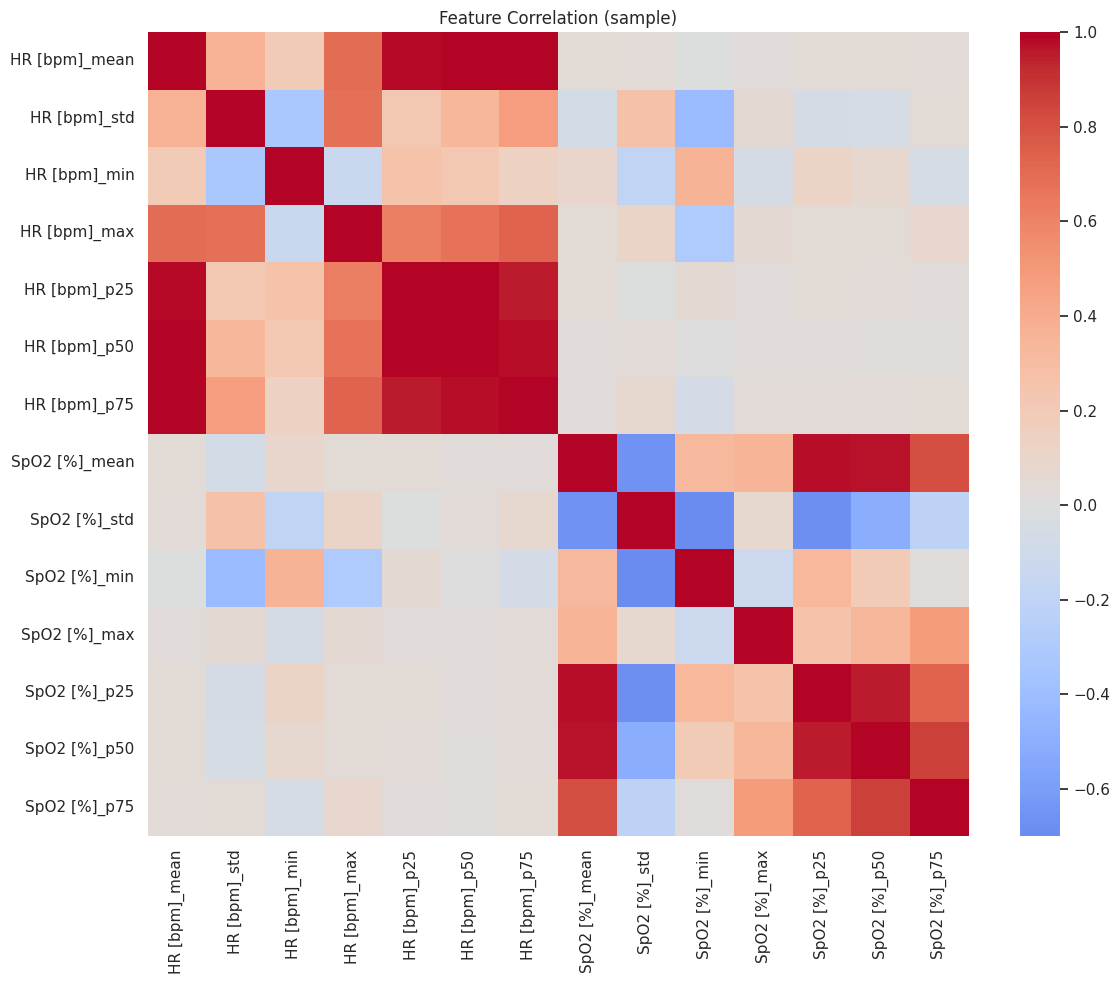


--- Training IsolationForest ---
Saved model to iforest_numeric_model.joblib
Saved labeled features to numeric_features_with_iforest_labels.csv

--- Model Evaluation & Quality Summary ---
Predicted label counts:
predicted_label
0    184
1     10
Name: count, dtype: int64
Anomaly ratio: 5.15% (config contamination=5.00%)

Top positive differences (Anomalous - Normal):
HR [bpm]_max     33.616667
HR [bpm]_p75     31.505556
HR [bpm]_mean    28.968020
HR [bpm]_p50     28.916667
HR [bpm]_p25     26.972222
HR [bpm]_min     16.766667
SpO2 [%]_std      4.693965
HR [bpm]_std      4.445326
SpO2 [%]_max     -1.359011
SpO2 [%]_p75     -3.756703
SpO2 [%]_p50     -6.446538
SpO2 [%]_mean    -6.895949
SpO2 [%]_p25     -8.316346
SpO2 [%]_min    -15.752967

Top features correlated with anomaly score:
HR [bpm]_mean   NaN
HR [bpm]_std    NaN
HR [bpm]_min    NaN
HR [bpm]_max    NaN
HR [bpm]_p25    NaN
HR [bpm]_p50    NaN
HR [bpm]_p75    NaN
SpO2 [%]_mean   NaN
SpO2 [%]_std    NaN
SpO2 [%]_min    NaN
SpO2 [

In [3]:
"""
Full Unsupervised Pipeline (Isolation Forest) for MIMIC-IV waveform numeric files
- Uses numeric files *n.csv.gz under DATA_ROOT
- Extracts summary features for selected signals
- Runs IsolationForest to detect anomalies (critical states)
- Produces EDA plots and a model-quality summary
- Saves outputs (CSV, model, scaler, plots)

Requirements:
pip install pandas numpy scikit-learn matplotlib seaborn joblib tqdm
"""

import os
import glob
import gzip
import math
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import joblib

# ---------------- USER CONFIG ----------------
DATA_ROOT = "physionet.org/files/mimic4wdb/0.1.0/waves"
NUMERIC_GLOB = os.path.join(DATA_ROOT, "**", "*n.csv.gz")
NUMERIC_COLUMNS_PREFERRED = [
    'HR [bpm]', 'SpO2 [%]', 'NBP Mean [mmHg]',
    'Systolic [mmHg]', 'Diastolic [mmHg]', 'Resp'
]
SAMPLE_LIMIT = None        # set to an int to limit files (useful for quick tests), or None for all files
CONTAMINATION = 0.05       # IsolationForest expected fraction of anomalies (tune if you like)
N_ESTIMATORS = 300
RANDOM_SEED = 42
MODEL_OUTPUT = "iforest_numeric_model.joblib"
SCALER_OUTPUT = "numeric_scaler.joblib"
FEATURES_CSV = "numeric_features_unlabeled.csv"
LABELED_CSV = "numeric_features_with_iforest_labels.csv"
PLOTS_DIR = "plots_iforest"
USE_RULE_BASED_COMPARISON = False   # set to True if you want to compute rule-based labels and compare

# Make sure plots dir exists
os.makedirs(PLOTS_DIR, exist_ok=True)
sns.set(style="whitegrid")

# ---------------- Helpers ----------------
def load_numeric_gz(path):
    """Load a numeric CSV.GZ file robustly into a pandas DataFrame (returns None on failure)."""
    try:
        with gzip.open(path, 'rt') as gf:
            df = pd.read_csv(gf)
        return df
    except Exception:
        try:
            return pd.read_csv(path, compression='gzip', engine='python')
        except Exception as e:
            print(f"[WARN] Failed to read {path}: {e}")
            return None

def make_summary_features(df, cols_of_interest):
    """
    Compute summary features for a numeric record DataFrame.
    Returns dict: feature_name -> value
    """
    feats = {}
    for c in cols_of_interest:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors='coerce').dropna()
            if s.size == 0:
                feats[f"{c}_mean"] = np.nan
                feats[f"{c}_std"] = np.nan
                feats[f"{c}_min"] = np.nan
                feats[f"{c}_max"] = np.nan
                feats[f"{c}_p25"] = np.nan
                feats[f"{c}_p50"] = np.nan
                feats[f"{c}_p75"] = np.nan
            else:
                feats[f"{c}_mean"] = float(s.mean())
                feats[f"{c}_std"] = float(s.std())
                feats[f"{c}_min"] = float(s.min())
                feats[f"{c}_max"] = float(s.max())
                feats[f"{c}_p25"] = float(np.percentile(s, 25))
                feats[f"{c}_p50"] = float(np.percentile(s, 50))
                feats[f"{c}_p75"] = float(np.percentile(s, 75))
        else:
            # column missing in this file -> fill NaNs for those features
            for suffix in ["mean", "std", "min", "max", "p25", "p50", "p75"]:
                feats[f"{c}_{suffix}"] = np.nan
    return feats

# Optional: simple rule-based label generator (used only if USER opts to)
CRITICAL_RULES = {
    'SpO2 [%]': lambda v: v < 90,
    'HR [bpm]': lambda v: v > 120,
    'NBP Mean [mmHg]': lambda v: v < 65
}
def derive_rule_label(df, rules=CRITICAL_RULES):
    if df is None or df.empty:
        return 0
    for col, rule in rules.items():
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors='coerce').dropna()
            if not vals.empty and vals.apply(rule).any():
                return 1
    return 0

# ---------------- 1) Discover numeric files & build features ----------------
print("Searching numeric files under:", DATA_ROOT)
numeric_files = sorted(glob.glob(NUMERIC_GLOB, recursive=True))
if SAMPLE_LIMIT is not None:
    numeric_files = numeric_files[:SAMPLE_LIMIT]
print("Found numeric files:", len(numeric_files))
if len(numeric_files) == 0:
    raise RuntimeError("No numeric files found. Check DATA_ROOT path.")

rows = []
for fpath in tqdm(numeric_files, desc="Processing numeric files"):
    df = load_numeric_gz(fpath)
    if df is None:
        continue
    feats = make_summary_features(df, NUMERIC_COLUMNS_PREFERRED)
    feats['file'] = fpath
    # optionally include rule label for later comparison if user wants (not used in training)
    if USE_RULE_BASED_COMPARISON:
        feats['rule_label'] = derive_rule_label(df)
    rows.append(feats)

feat_df = pd.DataFrame(rows)
print("Feature dataframe shape:", feat_df.shape)
feat_df.to_csv(FEATURES_CSV, index=False)
print("Saved feature table to", FEATURES_CSV)

# ---------------- 2) Clean features & quick preview ----------------
# Drop columns that are all NaN (rare but possible)
all_nan_cols = [c for c in feat_df.columns if feat_df[c].isna().all()]
if all_nan_cols:
    print("[INFO] Dropping all-NaN columns:", all_nan_cols)
    feat_df = feat_df.drop(columns=all_nan_cols)

# Preview
print("\nPreview of first 5 rows:")
display_cols = feat_df.columns[:min(10, len(feat_df.columns))]
print(feat_df.head()[display_cols].to_string(index=False))
print("\nColumns:", len(feat_df.columns))
print("Missing values per column (top 10):")
print(feat_df.isna().sum().sort_values(ascending=False).head(10))

# ---------------- 3) Prepare X (features) ----------------
# Keep the 'file' path separate and build X matrix
if 'file' not in feat_df.columns:
    raise RuntimeError("Expected 'file' column in features table.")
files = feat_df['file'].tolist()
X = feat_df.drop(columns=['file'])
# If rule label included, keep it aside
if USE_RULE_BASED_COMPARISON and 'rule_label' in X.columns:
    rule_labels = X['rule_label'].astype(int)
    X = X.drop(columns=['rule_label'])
else:
    rule_labels = None

# Fill per-column medians, then any leftover NaNs with 0
X = X.apply(lambda col: col.fillna(col.median()), axis=0)
X = X.fillna(0)
print("\nAfter cleaning, any NaNs left?", X.isnull().any().any())

# Save cleaned features (no file column)
CLEAN_FEATURES_CSV = "numeric_features_clean.csv"
pd.concat([pd.Series(files, name='file'), X.reset_index(drop=True)], axis=1).to_csv(CLEAN_FEATURES_CSV, index=False)
print("Saved cleaned features to", CLEAN_FEATURES_CSV)

# ---------------- 4) Scale features ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_OUTPUT)
print("Saved scaler to", SCALER_OUTPUT)

# ---------------- 5) EDA & Visualization ----------------
print("\n--- EDA & Visualization ---")
# 5a) Basic summary stats
desc = pd.DataFrame(X).describe().T
desc['missing'] = feat_df.drop(columns=['file']).isna().sum()
desc[['mean','std','min','25%','50%','75%','max','missing']].to_csv("feature_descriptive_stats.csv")
print("Saved feature descriptive stats to feature_descriptive_stats.csv")

# 5b) Distribution plots for top varying features
top_var = desc['std'].sort_values(ascending=False).head(6).index.tolist()
plt.figure(figsize=(14,8))
for i, col in enumerate(top_var, 1):
    plt.subplot(2,3,i)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(col)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "top_feature_distributions.png"))
plt.show()

# 5c) Correlation heatmap (limit to top 30 features or all if fewer)
corr_cols = X.columns.tolist()
if len(corr_cols) > 30:
    corr_cols = desc['std'].sort_values(ascending=False).head(30).index.tolist()
plt.figure(figsize=(12,10))
sns.heatmap(pd.DataFrame(X)[corr_cols].corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation (sample)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "correlation_heatmap.png"))
plt.show()



# ---------------- 6) Isolation Forest training ----------------
print("\n--- Training IsolationForest ---")
iso = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso.fit(X_scaled)
preds = iso.predict(X_scaled)          # 1 = normal, -1 = outlier
feat_df['anomaly_score'] = iso.decision_function(X_scaled)  # higher = more normal (by sklearn), lower = more abnormal
feat_df['predicted_label'] = np.where(preds == -1, 1, 0)   # map: 1 = anomaly/critical, 0 = normal

# Save labeled features
feat_df.to_csv(LABELED_CSV, index=False)
joblib.dump(iso, MODEL_OUTPUT)
print("Saved model to", MODEL_OUTPUT)
print("Saved labeled features to", LABELED_CSV)

# ---------------- 7) EVALUATION & MODEL QUALITY SUMMARY ----------------
print("\n--- Model Evaluation & Quality Summary ---")
anomaly_counts = feat_df['predicted_label'].value_counts()
anomaly_ratio = anomaly_counts.get(1, 0) / len(feat_df)
print("Predicted label counts:")
print(anomaly_counts)
print(f"Anomaly ratio: {anomaly_ratio:.2%} (config contamination={CONTAMINATION:.2%})")

# Feature differences (anomalous - normal)
numeric_features = [c for c in feat_df.columns if c not in ['file','anomaly_score','predicted_label']]
feature_means = feat_df.groupby('predicted_label')[numeric_features].mean().T
diff = (feature_means[1] - feature_means[0]).sort_values(ascending=False)
print("\nTop positive differences (Anomalous - Normal):")
print(diff.head(15).to_string())

# Correlation of anomaly_score with features
corr_with_score = pd.Series(data=np.nan, index=numeric_features)
for col in numeric_features:
    try:
        corr_with_score[col] = np.corrcoef(feat_df['anomaly_score'], feat_df[col])[0,1]
    except Exception:
        corr_with_score[col] = np.nan
corr_with_score = corr_with_score.sort_values(ascending=False)
print("\nTop features correlated with anomaly score:")
print(corr_with_score.head(15).to_string())

# Save metrics to CSV for reporting
pd.DataFrame({
    'feature': diff.index,
    'diff_anom_minus_norm': diff.values,
    'corr_with_score': corr_with_score.reindex(diff.index).values
}).to_csv("feature_anomaly_summary.csv", index=False)
print("Saved feature_anomaly_summary.csv")



# Show top anomalies
top_anomalies = feat_df.sort_values('anomaly_score').head(10)[['file','anomaly_score'] + numeric_features[:6]]
print("\nTop 10 most anomalous records (sample):")
print(top_anomalies.to_string(index=False))

# Stability check: re-fit with different seed and compare predictions
iso2 = IsolationForest(n_estimators=N_ESTIMATORS, contamination=CONTAMINATION, random_state=RANDOM_SEED+1, n_jobs=-1).fit(X_scaled)
preds2 = np.where(iso2.predict(X_scaled) == -1, 1, 0)
stability = np.mean(preds2 == feat_df['predicted_label'])
print(f"\nStability (retrain with different seed): {stability:.2%}")

# Pseudo-accuracy based on expected rate (informal)
expected_rate = CONTAMINATION
pseudo_accuracy = 1 - abs(expected_rate - anomaly_ratio)
print(f"Pseudo-Accuracy (based on expected anomaly rate): {pseudo_accuracy:.3f}")

# ---------------- 8) Optional: compare to rule-based labels (if user wants) ----------------
if USE_RULE_BASED_COMPARISON and rule_labels is not None:
    print("\n--- Comparing to rule-based labels (optional) ---")
    # ensure same length alignment
    comparison_df = pd.DataFrame({
        'file': feat_df['file'],
        'model_label': feat_df['predicted_label'],
        'rule_label': rule_labels.reset_index(drop=True)
    })
    # drop rows where rule_label is NaN
    comparison_df = comparison_df.dropna(subset=['rule_label'])
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
    print(classification_report(comparison_df['rule_label'], comparison_df['model_label'], digits=4, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(comparison_df['rule_label'], comparison_df['model_label']))
    try:
        probs = feat_df['anomaly_score']
        print("ROC AUC (model anomaly score vs rule_label):", roc_auc_score(comparison_df['rule_label'], probs.loc[comparison_df.index]))
    except Exception:
        pass

print("\nAll done. Outputs saved:")
print(" - cleaned features:", CLEAN_FEATURES_CSV)
print(" - unlabeled features:", FEATURES_CSV)
print(" - labeled features:", LABELED_CSV)
print(" - model:", MODEL_OUTPUT)
print(" - scaler:", SCALER_OUTPUT)
print(" - plots:", os.path.abspath(PLOTS_DIR))


In [4]:
# ======================
# ENSEMBLE WITH PIPELINE + STRATIFIED CV + SMOTEENN (Leakage-free)
# ======================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, roc_auc_score, precision_recall_curve, auc, fbeta_score

# === 1. Load your dataset ===
df = pd.read_csv("numeric_features_with_iforest_labels.csv")

# Drop non-numeric columns (like file paths)
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print(f"Dropping non-numeric columns: {non_numeric_cols}")
    df = df.drop(columns=non_numeric_cols)

X = df.drop("predicted_label", axis=1)
y = df["predicted_label"]

# === 2. Define base models ===
logreg = LogisticRegression(max_iter=500)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)
hgb = HistGradientBoostingClassifier(random_state=42)

# === 3. Ensemble (Voting) ===
ensemble = VotingClassifier(
    estimators=[
        ("lr", logreg),
        ("rf", rf),
        ("xgb", xgb),
        ("hgb", hgb)
    ],
    voting="soft"
)

# === 4. Custom scorers ===
def pr_auc_score(y_true, y_pred_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    return auc(recall, precision)

def f2_score(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)

# Define scorers for cross-validation
scorers = {
    "roc_auc": "roc_auc",
    "pr_auc": make_scorer(pr_auc_score, needs_proba=True),
    "f2": make_scorer(f2_score)
}

# === 5. Build pipeline (imputer → scaler → SMOTEENN → ensemble) ===
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smoteenn", SMOTEENN(random_state=42)),
    ("model", ensemble)
])

# === 6. Stratified K-Fold Cross-Validation ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === 7. Evaluate ===
cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scorers,
    n_jobs=-1,
    return_train_score=False
)

# === 8. Print results ===
print("\n===== AVERAGE CROSS-VALIDATION RESULTS (Voting Ensemble) =====")
print(f"Mean ROC AUC: {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")
print(f"Mean PR AUC:  {cv_results['test_pr_auc'].mean():.3f} ± {cv_results['test_pr_auc'].std():.3f}")
print(f"Mean F2:      {cv_results['test_f2'].mean():.3f} ± {cv_results['test_f2'].std():.3f}")


Dropping non-numeric columns: ['file']

===== AVERAGE CROSS-VALIDATION RESULTS (Voting Ensemble) =====
Mean ROC AUC: 0.992 ± 0.016
Mean PR AUC:  nan ± nan
Mean F2:      0.910 ± 0.117


In [5]:
# ======================
# ENSEMBLE WITH PIPELINE + STRATIFIED CV + SMOTEENN (Leakage-free)
# WITH INDIVIDUAL MODEL EVALUATION
# ======================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, roc_auc_score, precision_recall_curve, auc, fbeta_score, precision_score, recall_score, f1_score, accuracy_score

# === 1. Load your dataset ===
df = pd.read_csv("numeric_features_with_iforest_labels.csv")

# Drop non-numeric columns (like file paths)
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print(f"Dropping non-numeric columns: {non_numeric_cols}")
    df = df.drop(columns=non_numeric_cols)

X = df.drop("predicted_label", axis=1)
y = df["predicted_label"]

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")
print(f"Positive class ratio: {y.mean():.3f}")

# === 2. Define base models ===
logreg = LogisticRegression(max_iter=500, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)
hgb = HistGradientBoostingClassifier(random_state=42)

models = {
    "Logistic Regression": logreg,
    "Random Forest": rf,
    "XGBoost": xgb,
    "Hist Gradient Boosting": hgb
}

# === 3. Ensemble (Voting) ===
ensemble = VotingClassifier(
    estimators=[
        ("lr", logreg),
        ("rf", rf),
        ("xgb", xgb),
        ("hgb", hgb)
    ],
    voting="soft"
)

models["Voting Ensemble"] = ensemble

# === 4. Comprehensive Custom Scorers ===
def f2_score(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)

# Define comprehensive scorers for cross-validation (without PR_AUC)
scorers = {
    "roc_auc": "roc_auc",
    "f2": make_scorer(f2_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "accuracy": "accuracy"
}

# === 5. Function to evaluate individual models ===
def evaluate_model(model, model_name, X, y, cv, scorers):
    """Evaluate a single model with comprehensive metrics"""

    # Build pipeline for the model
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("smoteenn", SMOTEENN(random_state=42)),
        ("model", model)
    ])

    print(f"\n{'='*60}")
    print(f"EVALUATING: {model_name}")
    print(f"{'='*60}")

    # Perform cross-validation
    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scorers,
        n_jobs=-1,
        return_train_score=False
    )

    # Print results
    results_summary = {}
    for metric in scorers.keys():
        mean_score = cv_results[f'test_{metric}'].mean()
        std_score = cv_results[f'test_{metric}'].std()
        results_summary[metric] = (mean_score, std_score)
        print(f"{metric.upper():<12}: {mean_score:.4f} ± {std_score:.4f}")

    return results_summary

# === 6. Stratified K-Fold Cross-Validation ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === 7. Evaluate all models ===
all_results = {}

print("COMPREHENSIVE MODEL EVALUATION")
print("="*60)

# Evaluate individual models and ensemble
for model_name, model in models.items():
    results = evaluate_model(model, model_name, X, y, cv, scorers)
    all_results[model_name] = results

# === 8. Comparative Analysis ===
print(f"\n{'='*80}")
print("COMPARATIVE ANALYSIS OF ALL MODELS")
print(f"{'='*80}")

# Create comparison table
comparison_data = []
metrics = list(scorers.keys())

for model_name in models.keys():
    row = [model_name]
    for metric in metrics:
        mean, std = all_results[model_name][metric]
        row.append(f"{mean:.4f} ± {std:.4f}")
    comparison_data.append(row)

# Create and display comparison DataFrame
columns = ['Model'] + [metric.upper() for metric in metrics]
comparison_df = pd.DataFrame(comparison_data, columns=columns)

print("\nDetailed Comparison:")
print(comparison_df.to_string(index=False))

# === 9. Best Model Identification ===
print(f"\n{'='*60}")
print("BEST PERFORMING MODELS BY METRIC")
print(f"{'='*60}")

# Only show ROC_AUC, F2, and F1 (removed PR_AUC)
for metric in ['roc_auc', 'f2', 'f1']:
    best_model = None
    best_score = -1

    for model_name, results in all_results.items():
        score = results[metric][0]  # Mean score
        if score > best_score:
            best_score = score
            best_model = model_name

    print(f"{metric.upper():<10}: {best_model} ({best_score:.4f})")



Dropping non-numeric columns: ['file']
Dataset shape: (194, 15)
Class distribution: {0: 184, 1: 10}
Positive class ratio: 0.052
COMPREHENSIVE MODEL EVALUATION

EVALUATING: Logistic Regression
ROC_AUC     : 0.9108 ± 0.1070
F2          : 0.6442 ± 0.2592
PRECISION   : 0.5333 ± 0.2867
RECALL      : 0.7000 ± 0.2449
F1          : 0.5900 ± 0.2728
ACCURACY    : 0.9385 ± 0.0528

EVALUATING: Random Forest
ROC_AUC     : 0.9892 ± 0.0216
F2          : 0.8254 ± 0.2291
PRECISION   : 0.6733 ± 0.3058
RECALL      : 0.9000 ± 0.2000
F1          : 0.7505 ± 0.2646
ACCURACY    : 0.9590 ± 0.0476

EVALUATING: XGBoost
ROC_AUC     : 0.9811 ± 0.0265
F2          : 0.9000 ± 0.1333
PRECISION   : 0.7571 ± 0.3051
RECALL      : 1.0000 ± 0.0000
F1          : 0.8222 ± 0.2288
ACCURACY    : 0.9641 ± 0.0502

EVALUATING: Hist Gradient Boosting
ROC_AUC     : 0.9946 ± 0.0108
F2          : 0.9667 ± 0.0667
PRECISION   : 0.9000 ± 0.2000
RECALL      : 1.0000 ± 0.0000
F1          : 0.9333 ± 0.1333
ACCURACY    : 0.9897 ± 0.0205

EVA

In [8]:
# ---------------------------------------------------------------------------
# Section — Resource & Performance Profiling
# Measures memory, CPU utilization, energy consumption, throughput, and latency
# for the supervised pipeline models (Logistic Regression, RF, XGBoost, HGB, Ensemble)
# ---------------------------------------------------------------------------

import time
import threading
import os
import numpy as np
import pandas as pd
import psutil

try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
except ImportError:
    CODECARBON_AVAILABLE = False
    print("codecarbon not installed. Run `pip install codecarbon` for accurate energy tracking.\n"
          "Falling back to a rough CPU-time-based energy estimate.")

# Assumed average CPU power draw (W), used only in the fallback estimate
ASSUMED_CPU_POWER_WATTS = 45

process = psutil.Process(os.getpid())


class CPUMonitor:
    """Background thread sampling CPU utilization (%) at fixed intervals."""
    def __init__(self, interval=0.05):
        self.interval = interval
        self.samples = []
        self._running = False
        self._thread = None

    def _run(self):
        while self._running:
            self.samples.append(psutil.cpu_percent(interval=None))
            time.sleep(self.interval)

    def start(self):
        self.samples = []
        self._running = True
        psutil.cpu_percent(interval=None)  # prime it (first call always returns 0.0)
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self):
        self._running = False
        if self._thread is not None:
            self._thread.join(timeout=1)
        return np.mean(self.samples) if self.samples else 0.0


def profile_model(name, predict_fn, X_test, n_latency_samples=200):
    """
    Profiles a model's inference given a callable predict_fn(X) -> predictions.
      - Memory consumption (RSS delta, MB)
      - Avg CPU utilization (%) during batch inference
      - Energy (kWh) via codecarbon, or a CPU-time-based estimate
      - Throughput (samples/sec) from batch inference
      - Latency (ms/sample, mean and p95) from single-sample inference
    """
    X_test_arr = np.asarray(X_test)
    n_samples = len(X_test_arr)

    mem_before = process.memory_info().rss / (1024 ** 2)  # MB

    cpu_monitor = CPUMonitor()
    tracker = None
    if CODECARBON_AVAILABLE:
        tracker = EmissionsTracker(project_name=f"mimic_{name}", measure_power_secs=1,
                                    save_to_file=False, log_level="error")
        tracker.start()

    cpu_monitor.start()
    t0 = time.perf_counter()
    _ = predict_fn(X_test_arr)
    t1 = time.perf_counter()
    avg_cpu = cpu_monitor.stop()

    energy_kwh = None
    if tracker is not None:
        try:
            energy_kwh = tracker.stop()
        except Exception:
            energy_kwh = None

    batch_time = t1 - t0
    throughput = n_samples / batch_time if batch_time > 0 else float('nan')

    mem_after = process.memory_info().rss / (1024 ** 2)
    mem_delta = max(mem_after - mem_before, 0)

    if energy_kwh is None:
        cpu_seconds = batch_time * (avg_cpu / 100.0)
        energy_kwh = (ASSUMED_CPU_POWER_WATTS * cpu_seconds) / 3600 / 1000

    # Single-sample latency loop
    idx = np.random.choice(n_samples, size=min(n_latency_samples, n_samples), replace=False)
    single_times = []
    for i in idx:
        sample = X_test_arr[i:i + 1]
        ts = time.perf_counter()
        _ = predict_fn(sample)
        te = time.perf_counter()
        single_times.append((te - ts) * 1000)  # ms

    return {
        'Model': name,
        'Memory (MB)': round(mem_delta, 3),
        'Avg CPU Utilization (%)': round(avg_cpu, 2),
        'Energy (kWh)': energy_kwh,
        'Throughput (samples/sec)': round(throughput, 2),
        'Latency Mean (ms/sample)': round(float(np.mean(single_times)), 4),
        'Latency P95 (ms/sample)': round(float(np.percentile(single_times, 95)), 4),
        'Batch Inference Time (s)': round(batch_time, 4),
        'Test Samples': n_samples
    }


results = []

# Refit and profile the supervised pipeline models
# cross_validate() doesn't retain fitted models, so we refit each pipeline once
# on the full dataset purely to obtain a model object for profiling.
# Note: SMOTEENN only runs during .fit(), not .predict(), so it does not affect
# the inference timing measured below.
if 'models' in globals() and 'X' in globals() and 'y' in globals():
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from imblearn.combine import SMOTEENN
    from imblearn.pipeline import Pipeline

    for model_name, base_model in models.items():
        print(f"Fitting + profiling {model_name} ...")
        try:
            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("smoteenn", SMOTEENN(random_state=42)),
                ("model", base_model)
            ])
            pipe.fit(X, y)
            results.append(profile_model(model_name, pipe.predict, X))
        except Exception as e:
            print(f"  Failed to profile {model_name}: {e}")

profile_df = pd.DataFrame(results)
profile_df

codecarbon not installed. Run `pip install codecarbon` for accurate energy tracking.
Falling back to a rough CPU-time-based energy estimate.
Fitting + profiling Logistic Regression ...


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/v

Fitting + profiling Random Forest ...


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/v

Fitting + profiling XGBoost ...


...

Fitting + profiling Hist Gradient Boosting ...


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/v

Fitting + profiling Voting Ensemble ...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [05:19:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/loca

,Model,Memory (MB),Avg CPU Utilization (%),Energy (kWh),Throughput (samples/sec),Latency Mean (ms/sample),Latency P95 (ms/sample),Batch Inference Time (s),Test Samples
0,Logistic Regression,0.000,0.0,0.0,27505.25,2.4679,5.4230,0.0071,194
1,Random Forest,0.000,0.0,0.0,12901.98,26.5430,50.5178,0.0150,194
2,XGBoost,0.000,0.0,0.0,16560.26,3.2590,8.0376,0.0117,194
3,Hist Gradient Boosting,0.000,0.0,0.0,45668.31,3.7880,7.9418,0.0042,194
4,Voting Ensemble,0.004,0.0,0.0,9846.83,17.3507,41.0432,0.0197,194


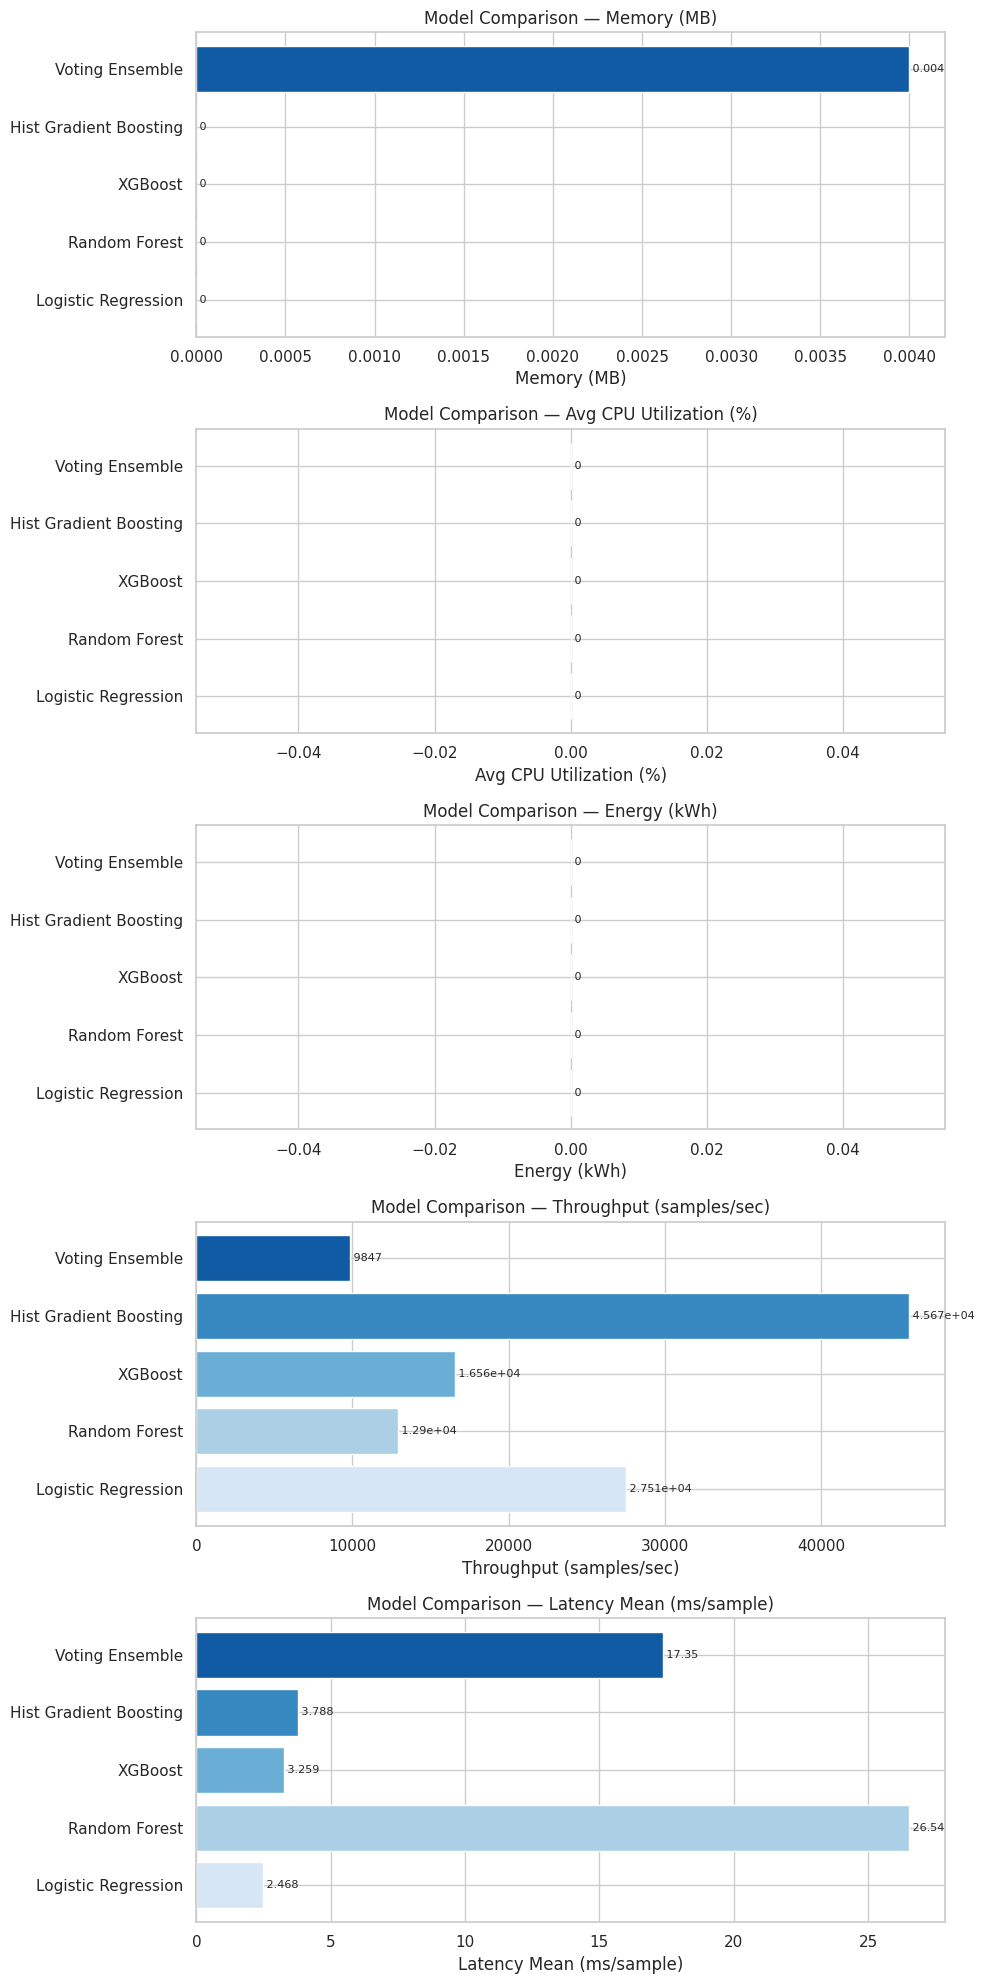

In [9]:
metrics = ['Memory (MB)', 'Avg CPU Utilization (%)', 'Energy (kWh)',
           'Throughput (samples/sec)', 'Latency Mean (ms/sample)']

fig, axs = plt.subplots(len(metrics), 1, figsize=(10, 4 * len(metrics)))
colors = sns.color_palette('Blues', n_colors=len(profile_df))

for ax, metric in zip(axs, metrics):
    ax.barh(profile_df['Model'], profile_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'Model Comparison — {metric}')
    for i, v in enumerate(profile_df[metric]):
        ax.text(v, i, f' {v:.4g}', va='center', fontsize=8)

plt.tight_layout()
plt.show()